# <font color='black'>Регрессионный анализ: панельные данные и каузальность, 2026 </font>
## <font color='black'> Метод разрывной регрессии </font>

Источник данных: Manacorda, Marco, Edward Miguel, and Andrea Vigorito. 2011. “Government Transfers and Political Support.” American Economic Journal: Applied Economics 3 (3): 1–28


В этом исследовании рассматривается эффект программы национальной помощи бедным, реализуемой в Уругвае в 2005 - 2007 гг. (The Plan de Atención Nacional a la Emergencia Sociál). Участники программы получали в качестве помощи социальные выплаты. Кроме того, семьи с детьми получали продовольственную карту, а также некоторые дополнительные льготы. Авторов статьи интересовало, повлияло ли получение этих средств на поддержку недавно пришедшего к власти левоцентристского правительства, которое инициировало эти выплаты.

Для участия в программе требовался достаточно низкий доход. Правительство применяло множество факторов — жилищные условия, занятость, заявленный доход и образование — для прогнозирования дохода. Именно этот прогнозируемый доход служил переменной назначения в рамках метода разрывной регрессии, а право на получение помощи определялось на основе нахождения ниже установленного порога. Около 14% населения получили выплаты

Исследователи опросили людей, чей прогнозируемый доход был близок к пороговому значению, чтобы измерить их поддержку правительства после получения помощи. В массиве данных переменная назначения (прогнозируемый доход) уже центрирована так, что пороговое значение находится на нуле. Поддержка правительства измеряется по трёхбалльной шкале:
* респондент считает новое правительство лучше предыдущего - 1 балл
* считает таким же - 0,5 балла
* оценивает хуже предыдущего - 0 баллов


In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess
import statsmodels.formula.api as smf

!pip install rdrobust
from rdrobust import rdrobust, rdplot, rdbwselect

!pip install causaldata
from causaldata import gov_transfers

In [80]:
d = gov_transfers.load_pandas().data
d.head()

,Income_Centered,Education,Age,Participation,Support
0,0.006571,3.5,23.666666,0,1.0
1,0.011075,1.5,42.000000,0,1.0
2,0.002424,4.0,43.000000,0,1.0
3,0.007650,6.0,21.000000,0,0.5
4,0.010001,2.0,33.000000,0,1.0


Построим сглаженный график, который будет показывать зависимост поддержки правительства от переменной назначения - прогнозируемого дохода. В данном случае используем локально-взвешенное сглаживание. Для каждой точки используется 10% наблюдений (прописываем в коде это через frac = 0.1). Этот график позволит нам визуально оценить, есть ли скачок в уровне поддержки правительства именно в точке разрыва (пороговое значение дохода для назначения пособия - на графике это значение покажем, зафиксируя в соответствующей точке вертикальную разделительную черту)

Text(0, 0.5, 'Поддержка правительства')

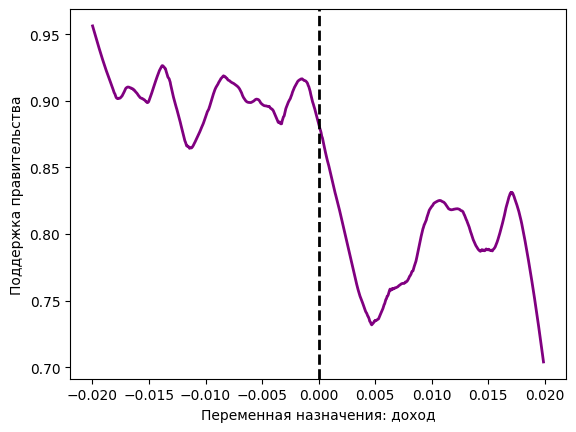

In [81]:
x = d['Income_Centered'].values
y = d['Support'].values

smoothed = lowess(y, x, frac=0.1, return_sorted=True)
plt.plot(smoothed[:,0], smoothed[:,1], 'purple', linewidth=2)
plt.axvline(x=0, color='black', linestyle='--', linewidth=2)
plt.xlabel('Переменная назначения: доход')
plt.ylabel('Поддержка правительства')

Или в качестве альтернативы можно использовать график, построенный автоматически при помощи функции rdplot. Здесь подбирается количество интервалов и полиномиальная функция отдельно слева и справа от пороговой точки

Mass points detected in the running variable.


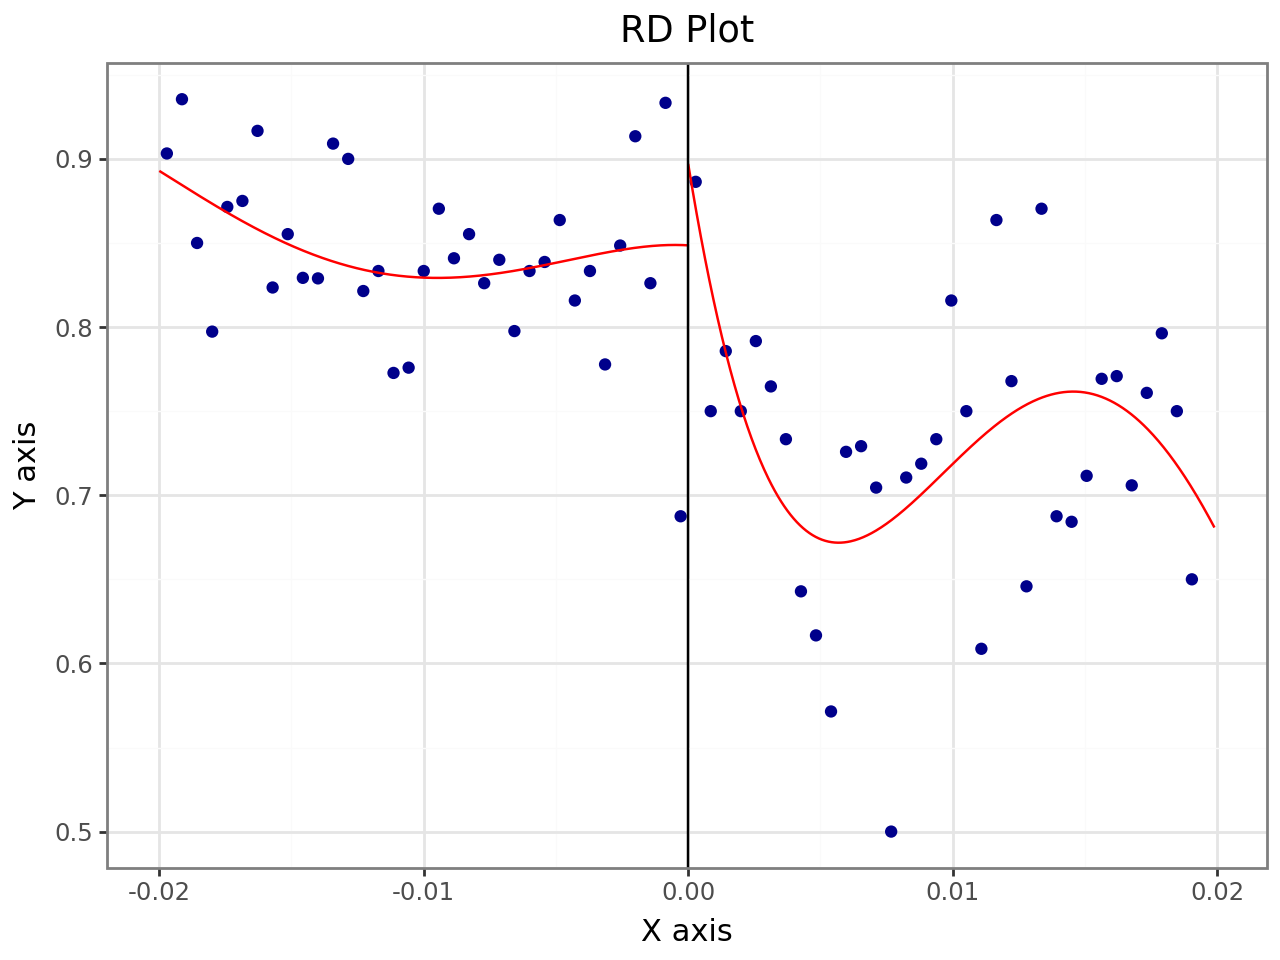

Call: rdplot
Number of Observations:                  1948
Kernel:                               Uniform
Polynomial Order Est. (p):                  4

                                Left      Right
------------------------------------------------
Number of Observations          1127        821
Number of Effective Obs         1127        821
Bandwidth poly. fit (h)         0.02       0.02
Number of bins scale               1          1
Bins Selected                     35         35
Average Bin Length             0.001      0.001
Median Bin Length              0.001      0.001
IMSE-optimal bins                3.0        7.0
Mimicking Variance bins         35.0       35.0

Relative to IMSE-optimal:
Implied scale                 11.667        5.0
WIMSE variance weight          0.001      0.008
WIMSE bias weight              0.999      0.992

In [82]:
rdplot(d['Support'], d['Income_Centered'])

Построим гистограмму для переменной прогнозируемого дохода для того, чтобы понять, есть ли свидетельства о манипуляции результатами (внешнего вмешательства):

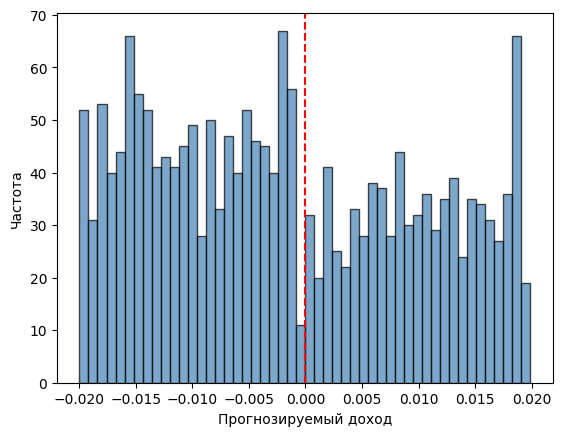

In [83]:
plt.hist(d['Income_Centered'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--')
plt.xlabel('Прогнозируемый доход')
plt.ylabel('Частота')
plt.show()

Для того, чтобы оценить линейную регрессию разрывного дизайна, предварительно определим параметр bandwidth ("ширину окна"). Устанавливаем p = 1 - это соответствует линейной регрессии, bwselect = 'mserd' - находим такое "окно", чтобы MSE (среднеквадратичная ошибка) была минимизирована. Порог здесь по умолчанию 0

In [84]:
bw1 = rdbwselect(d['Support'], d['Income_Centered'], p = 1, bwselect='mserd')
h = bw1.bws
h

Mass points detected in the running variable.


,h (left),h (right),b (left),b (right)
mserd,0.00522,0.00522,0.010255,0.010255


Сохраним в массиве только те наблюдения, которые попадают в диапазон значений [c-h; c+h]

In [85]:
h_value = h['h (left)'].item()
d_bw1 = d[d['Income_Centered'].abs() <= h_value].copy()

Оценим в соответствии с четким дизайном исследования RDD линейную модель с разными наклонами для группы воздействия и контрольной группы:

In [86]:
m1 = smf.ols('Support ~ Income_Centered * Participation', data=d_bw1).fit(cov_type = "HC3")
print(m1.summary())

                            OLS Regression Results                            
Dep. Variable:                Support   R-squared:                       0.052
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     6.520
Date:                Tue, 26 May 2026   Prob (F-statistic):           0.000249
Time:                        10:06:03   Log-Likelihood:                -103.40
No. Observations:                 485   AIC:                             214.8
Df Residuals:                     481   BIC:                             231.5
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

Теперь давайте используем взвешивание наблюдений: в соответствии с треугольным ядром (kernel = 'triangular': функция, которая будет приписывать больший вес наблюдениям ближе к порогому значению, а тем наблюдениям, которые находятся дальше, будет приписываться меньший вес)

In [87]:
d['Income_Centered_inversed'] = (-1)*d['Income_Centered']

In [88]:
rdd_model1 = rdrobust(d['Support'], d['Income_Centered_inversed'], c=0,
                     p=1, kernel='triangular', bwselect = "mserd")

print(rdd_model1)

Mass points detected in the running variable.
Call: rdrobust

Sharp RD estimates using local polynomial regression.

Number of Observations:                  1948
Polynomial Order Est. (p):                  1
Polynomial Order Bias (q):                  2
Kernel:                            Triangular
Bandwidth Selection:                    mserd
Var-Cov Estimator:                         NN

                                Left      Right
------------------------------------------------
Number of Observations           821       1127
Number of Unique Obs.            639        841
Number of Effective Obs.         194        291
Bandwidth Estimation           0.005      0.005
Bandwidth Bias                  0.01       0.01
rho (h/b)                      0.509      0.509

Method             Coef.     S.E.   z-stat    P>|z|       95% CI      
-------------------------------------------------------------------------
Conventional      -0.025    0.062   -0.396   6.920e-01    [-0.147, 0.098]
R

На первом графике зависимости поддержки правительства от переменной назначения - прогнозируемого дохода - мы заметили, что функциональная форма здесь нелинейная. Поэтому дополнительно оценим еще модель с квадратичным эффектом прогнозируемого дохода

In [89]:
bw2 = rdbwselect(d['Support'], d['Income_Centered'], p = 2, bwselect='mserd')
h2 = bw2.bws
h2

Mass points detected in the running variable.


,h (left),h (right),b (left),b (right)
mserd,0.007348,0.007348,0.011425,0.011425


In [90]:
h2_value = h2['h (left)'].item()
d_bw2 = d[d['Income_Centered'].abs() <= h2_value].copy()

In [91]:
m2 = smf.ols('Support~Income_Centered*Participation + I(Income_Centered**2)*Participation', data = d_bw2).fit(cov_type = "HC3")
print(m2.summary())

                            OLS Regression Results                            
Dep. Variable:                Support   R-squared:                       0.048
Model:                            OLS   Adj. R-squared:                  0.041
Method:                 Least Squares   F-statistic:                     5.814
Date:                Tue, 26 May 2026   Prob (F-statistic):           2.86e-05
Time:                        10:06:03   Log-Likelihood:                -174.25
No. Observations:                 688   AIC:                             360.5
Df Residuals:                     682   BIC:                             387.7
Df Model:                           5                                         
Covariance Type:                  HC3                                         
                                            coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

In [92]:
rdd_model2 = rdrobust(d['Support'], d['Income_Centered_inversed'], c=0,
                     p=2, kernel='triangular', bwselect = "mserd")

print(rdd_model2)

Mass points detected in the running variable.
Call: rdrobust

Sharp RD estimates using local polynomial regression.

Number of Observations:                  1948
Polynomial Order Est. (p):                  2
Polynomial Order Bias (q):                  3
Kernel:                            Triangular
Bandwidth Selection:                    mserd
Var-Cov Estimator:                         NN

                                Left      Right
------------------------------------------------
Number of Observations           821       1127
Number of Unique Obs.            639        841
Number of Effective Obs.         281        407
Bandwidth Estimation           0.007      0.007
Bandwidth Bias                 0.011      0.011
rho (h/b)                      0.643      0.643

Method             Coef.     S.E.   z-stat    P>|z|       95% CI      
-------------------------------------------------------------------------
Conventional      -0.083    0.084   -0.984   3.251e-01    [-0.247, 0.082]
R

В нашем случае переменная Participation полностью определяется переменной назначения (в зависимости от того пересекается ли порог, значения 0 или 1 присваиваются Participation). Однако что если есть фактические данные о получении социальных выплат не соответствуют статусу, определенным переменной назначения? Сгенерим дополнительно такую переменную treatment_fuzzy, которая будет показывать, фактически были ли полученые социальные выплаты

In [93]:
np.random.seed(101)

prob_noncompliance = 0.15

noncompliance = np.random.binomial(1, prob_noncompliance, size=len(d))

d['treatment_fuzzy'] = np.where(noncompliance == 1, 1 - d['Participation'], d['Participation'])

In [94]:
d['treatment_fuzzy'].describe()

,treatment_fuzzy
count,1948.000000
mean,0.551848
std,0.497432
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


Далее оценим модели RDD при помощи fuzzy design

In [95]:
fuzzy_rdd_result = rdrobust(d['Support'], d['Income_Centered_inversed'], fuzzy=d['treatment_fuzzy'], p=1,
                            kernel='triangular', bwselect='mserd'
)

print(fuzzy_rdd_result)

Mass points detected in the running variable.
Call: rdrobust

Fuzzy RD estimates using local polynomial regression.

Number of Observations:                  1948
Polynomial Order Est. (p):                  1
Polynomial Order Bias (q):                  2
Kernel:                            Triangular
Bandwidth Selection:                    mserd
Var-Cov Estimator:                         NN

                                Left      Right
------------------------------------------------
Number of Observations           821       1127
Number of Unique Obs.            639        841
Number of Effective Obs.         278        407
Bandwidth Estimation           0.007      0.007
Bandwidth Bias                 0.012      0.012
rho (h/b)                      0.607      0.607

Method             Coef.     S.E.   z-stat    P>|z|       95% CI      
-------------------------------------------------------------------------
Conventional       0.005    0.081    0.062   9.502e-01    [-0.154, 0.164]
R

In [96]:
fuzzy_rdd_result = rdrobust(d['Support'], d['Income_Centered_inversed'], fuzzy=d['treatment_fuzzy'], p=2,
                            kernel='triangular', bwselect='mserd'
)

print(fuzzy_rdd_result)

Mass points detected in the running variable.
Call: rdrobust

Fuzzy RD estimates using local polynomial regression.

Number of Observations:                  1948
Polynomial Order Est. (p):                  2
Polynomial Order Bias (q):                  3
Kernel:                            Triangular
Bandwidth Selection:                    mserd
Var-Cov Estimator:                         NN

                                Left      Right
------------------------------------------------
Number of Observations           821       1127
Number of Unique Obs.            639        841
Number of Effective Obs.         281        407
Bandwidth Estimation           0.007      0.007
Bandwidth Bias                 0.011      0.011
rho (h/b)                      0.684      0.684

Method             Coef.     S.E.   z-stat    P>|z|       95% CI      
-------------------------------------------------------------------------
Conventional      -0.153    0.159   -0.966   3.339e-01    [-0.465, 0.158]
R